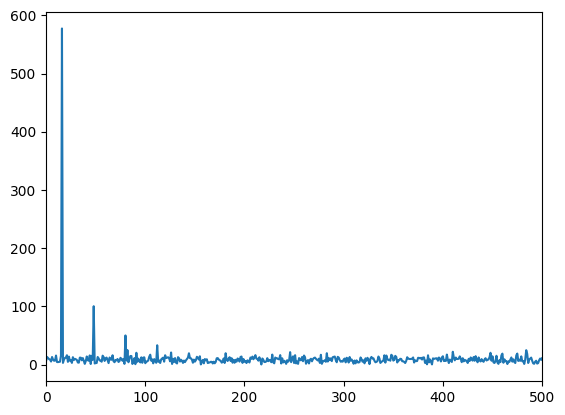

In [ ]:
#dft
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k] +=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c
y=np.loadtxt("pitch.txt",float)
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()



1000


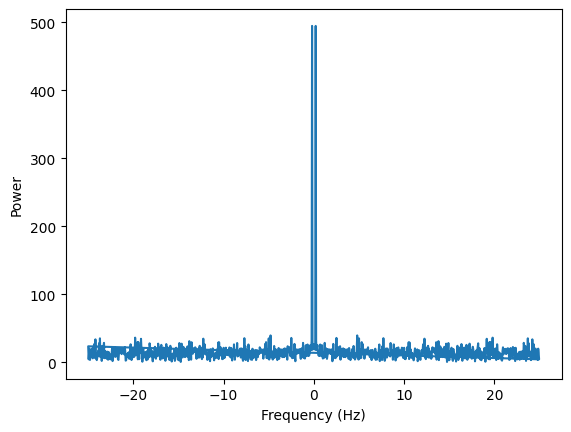

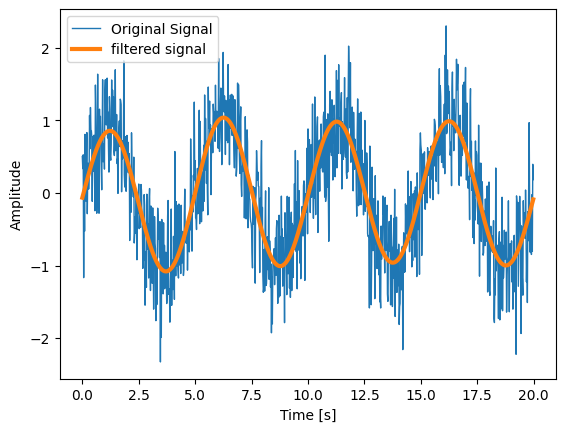

In [ ]:
import scipy.fftpack
import numpy as np
import matplotlib.pyplot as plt


time_step=0.02
period=5.0

time_vec=np.arange(0,20,time_step)
sig=(np.sin(2*np.pi/period*time_vec)+0.5*np.random.randn(time_vec.size))
sig_fft=scipy.fftpack.fft(sig)
power=np.abs(sig_fft)   #amplitude(진폭)
print(sig.size) #sig의 크기
sample_freq=scipy.fftpack.fftfreq(sig.size,d=time_step)
plt.plot(sample_freq,power)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

pos_mask=np.where(sample_freq>0)
freqs=sample_freq[pos_mask]
peak_freq=freqs[power[pos_mask].argmax()]

high_freq_fft=sig_fft.copy()
high_freq_fft[np.abs(sample_freq)>peak_freq]=0

filtered_sig=scipy.fftpack.ifft(high_freq_fft)
plt.plot(time_vec,sig,lw=1,label='Original Signal')
plt.plot(time_vec,filtered_sig.real,lw=3,label='filtered signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()



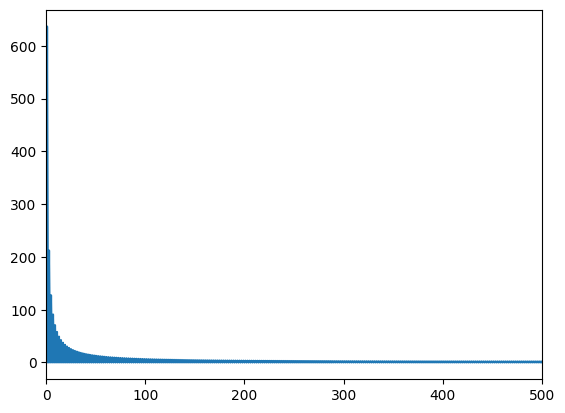

In [ ]:
#연습 7.1(푸리에 변환의 원리)
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c
y=np.ones(1000)
y[500:]=-1.0
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()


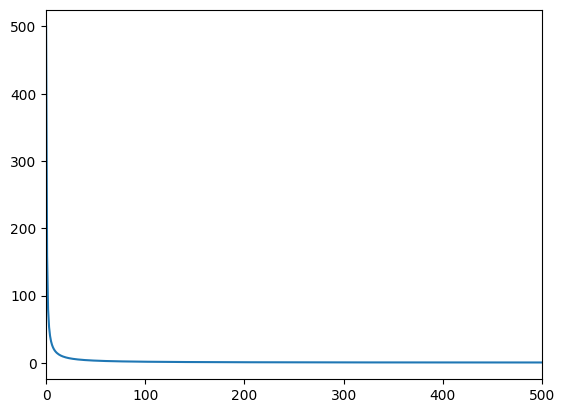

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c

y=np.linspace(0,1,1000)
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c



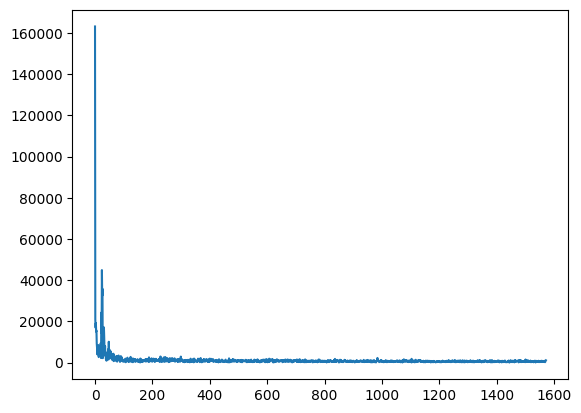

In [ ]:
#exercise 7.2(b)
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y[:,1])
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[:,1][n]*np.exp(-2j*np.pi*k*n/N)
  return c

y=np.loadtxt("sunspots.txt",float)
b=dft(y)
plt.plot(abs(b))
plt.show()




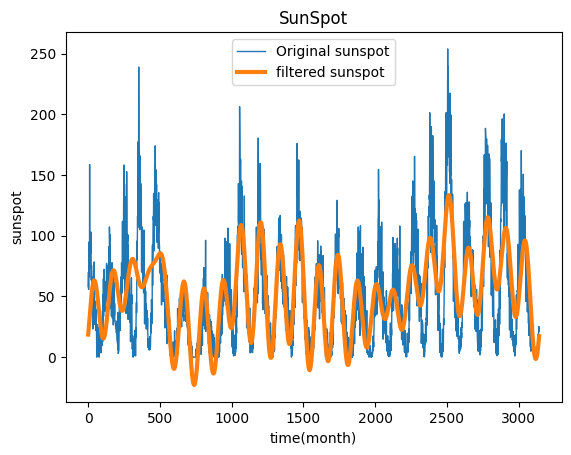

In [31]:
from scipy.fft import rfft,rfftfreq,irfft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("sunspots.txt",float)
y_rfft=rfft(y[:,1])
power=(np.abs(y_rfft))**2
sample_freq=rfftfreq(y[:,1].size,1/12)
pos_mask=np.where(sample_freq>0)
freq=sample_freq[pos_mask]
peak_freq=freq[power[pos_mask].argmax()]

high_freq_fft=y_rfft.copy()
high_freq_fft[np.abs(sample_freq)>peak_freq]=0

filtered_sig=scipy.fft.irfft(high_freq_fft, n=y[:,1].size)

plt.plot(y[:,0],y[:,1],lw=1,label='Original sunspot')
plt.plot(y[:,0],filtered_sig.real,lw=3,label='filtered sunspot')
plt.xlabel('time(month)')
plt.ylabel('sunspot')
plt.legend()
plt.title("SunSpot")
plt.show()

/tmp/ipykernel_8738/435483828.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


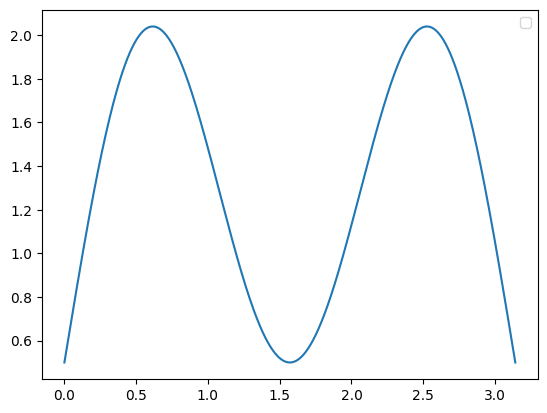

In [ ]:
#이산 코사인,사인 변환(scipy.dct,scipy.dst)
import numpy as np
from scipy.fft import dct,idct,dst,idst
import matplotlib.pyplot as plt

x=np.linspace(0,np.pi,1000)
y=np.sin(x)+0.5+np.sin(3*x)

y_dct=dct(y,type=2)
y_dct_recovered=idct(y_dct,type=2)

y_dst=dst(y,type=2)
y_dst_recovered=idst(y_dst,type=2)

plt.plot(x,y)
plt.legend()
plt.show()




In [ ]:
#exercise7.3 fourier transforms of musical instruments
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("piano.txt",float)

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c

c=dft(y)
plt.plot(abs(c))
plt.show

#자체 함수를 쓸땐 복소수 곱셈을 100억번을 해야된다.

KeyboardInterrupt: 

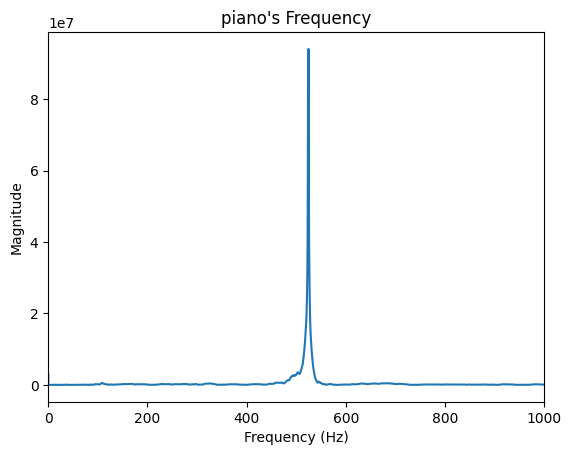

In [ ]:
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("piano.txt",float)
N=len(y)
sample_rate=44100
dt=1/sample_rate
c=scipy.fft.fft(y)
d=scipy.fft.fftshift(c)
freqs=scipy.fft.fftshift(scipy.fft.fftfreq(N,dt))
plt.plot(freqs,abs(d))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0,1000)
plt.title("piano's Frequency")
plt.show()


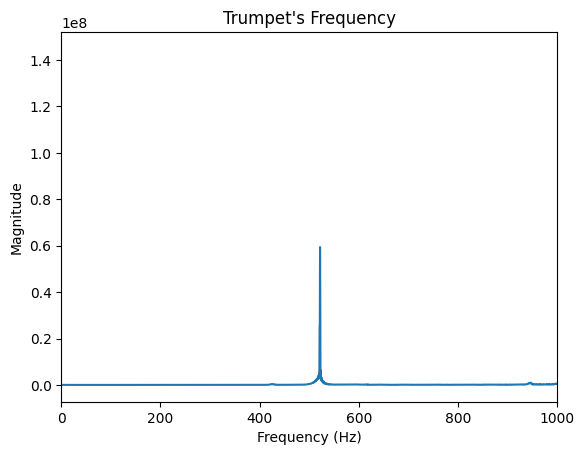

In [ ]:
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("trumpet.txt",float)
N=len(y)
sample_rate=44100
dt=1/sample_rate
c=scipy.fft.fft(y)
d=scipy.fft.fftshift(c)
freq=scipy.fft.fftshift(scipy.fft.fftfreq(N,dt))
plt.plot(freqs,abs(d))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0,1000)
plt.title("Trumpet's Frequency")
plt.show()



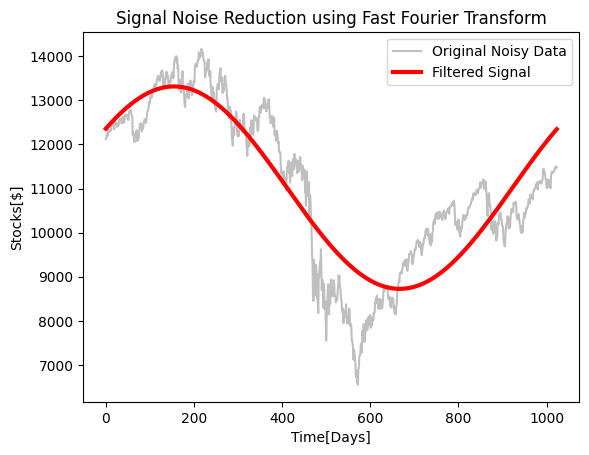

In [30]:
#7.4 문제
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("dow.txt",float)
d=scipy.fft.rfft(y)
dow_freq=scipy.fft.rfftfreq(len(y),1/365)

tenper=np.where(dow_freq<0.6)
nineper=np.where(dow_freq>0.6)
d[nineper]=0

sig=scipy.fft.irfft(d,n=len(y))
plt.plot(y, label='Original Noisy Data',alpha=0.5, color='gray')
plt.plot(sig,label='Filtered Signal',lw=3,color='red')
plt.legend()
plt.xlabel('Time[Days]')
plt.ylabel('Stocks[$]')
plt.title("Signal Noise Reduction using Fast Fourier Transform")
plt.show()
